# The predictive analytic Engine


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.family'] = 'sans-serif'

In [4]:


data = pd.read_csv(r"C:\Users\PC\Pydata-Capstone-Project\DATA\Kenya_Rainfall data.csv")
data.columns



Index(['date', 'adm_level', 'PCODE', 'current_rainfall',
       'historical_rainfall_avg', 'rolling_3_month_avg', 'r3h_avg', 'rfq',
       'seasonal_anomaly_score', 'year', 'month', 'deficit'],
      dtype='str')

In [7]:
planting_season = data[data["month"].isin([3,4,5])].copy()
planting_season["PCODE"] = planting_season["PCODE"].astype(str).str.strip().str.upper()
planting_season = planting_season[planting_season["month"].isin([3,4,5])].copy()
planting_season["seasonal_anomaly_score"] = planting_season["current_rainfall"] - planting_season["historical_rainfall_avg"]

print(f"Data isolated successfully. Total rows for analysis: {len(planting_season)}")


Data isolated successfully. Total rows for analysis: 3645


In [9]:
# Calculate absolute total volumes, expected averages, and percentage deficits
PCODE_total = (
    planting_season.groupby("PCODE")
    .agg(Total_Actual=("current_rainfall", "sum"), Total_Expected=("historical_rainfall_avg", "sum"))
    .reset_index()
)

# Derive missing rainfall and enforce a baseline floor of 0 for surplus counties
PCODE_total["Deficit_mm"] = (
    PCODE_total["Total_Expected"] - PCODE_total["Total_Actual"]
).clip(lower=0)

# Calculate Core Metric: Percentage of Expected Rain Missing
PCODE_total["Deficit_Percentage"] = (
    PCODE_total["Deficit_mm"] / PCODE_total["Total_Expected"]
) * 100

print("Solution 1 Engine: Chronic Deficit calculations complete.")
print(PCODE_total.head())

Solution 1 Engine: Chronic Deficit calculations complete.
      PCODE  Total_Actual  Total_Expected  Deficit_mm  Deficit_Percentage
0  KE001003   2613.900000     2923.649960  309.749960           10.594632
1  KE002010   1936.695164     2121.672250  184.977086            8.718457
2  KE003015   1861.616881     2129.719745  268.102864           12.588645
3  KE003017   1632.676000     1726.081355   93.405355            5.411411
4     KE004   1268.347381     1276.955450    8.608068            0.674109


In [11]:

PCODE_whiplash = planting_season.groupby(["PCODE", "year"])["seasonal_anomaly_score"].sum().reset_index()
PCODE_volatility = (
    PCODE_whiplash.groupby("PCODE")["seasonal_anomaly_score"]
    .std()
    .reset_index()
    .rename(columns={"seasonal_anomaly_score": "Whiplash_Score"})
)
print(PCODE_volatility.head())


      PCODE  Whiplash_Score
0  KE001003      118.552718
1  KE002010       73.112950
2  KE003015       68.982921
3  KE003017       73.323552
4     KE004       56.262968


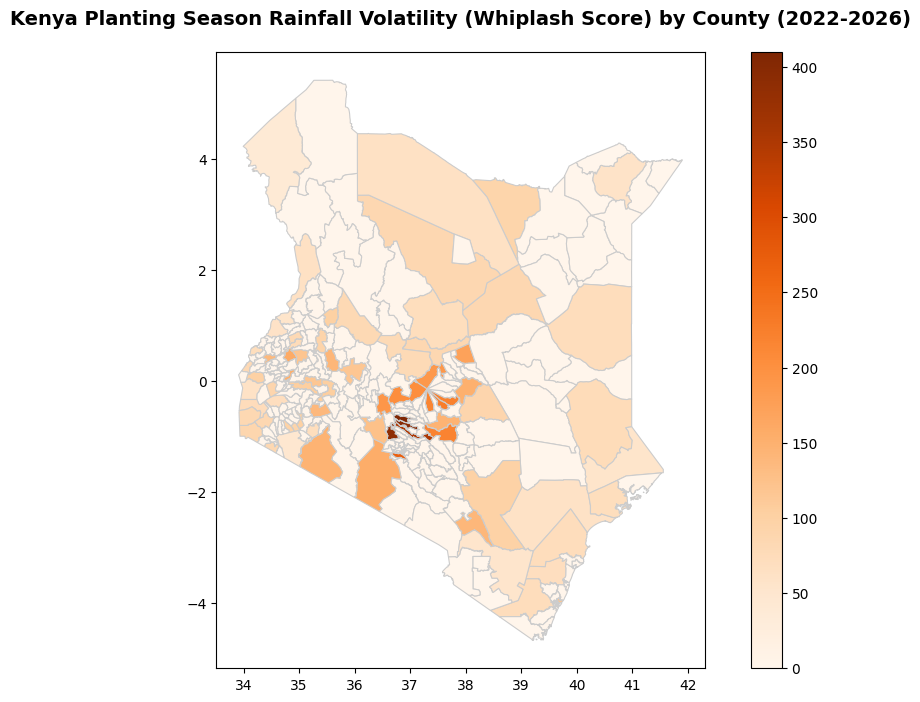

In [14]:


# Load the official Kenyan spatial map file
spatial_map = gpd.read_file(r"C:\Users\PC\Downloads\ken_admin_boundaries.geojson\ken_admin2.geojson")
# Only drops columns where all rows are completely empty
cleaned_spatial_map = spatial_map.dropna(axis=1, how="all")
cleaned_spatial_map['adm2_pcode'] = (
    cleaned_spatial_map['adm2_pcode'].astype(str).str.strip().str.upper()
)
merged_map = cleaned_spatial_map.merge(
    PCODE_total,
    left_on='adm2_pcode',
    right_on='PCODE',
    how='left'
)
merged_map = merged_map.merge(PCODE_volatility, on='PCODE', how='left')
merged_map["Deficit_Percentage"] = merged_map["Deficit_Percentage"].fillna(0)
merged_map["Whiplash_Score"] = merged_map["Whiplash_Score"].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
merged_map.plot(column="Whiplash_Score", cmap="Oranges", linewidth=0.8, ax=ax, edgecolor="0.8", legend=True)
plt.title("Kenya Planting Season Rainfall Volatility (Whiplash Score) by County (2022-2026)", fontsize=14, fontweight="bold", pad=20)
plt.show()

In [15]:
# Automated Last_Mile Alerts
def simulate_last_mile_alert(input_pcode):
    """Simulates the automated Solution 2 logic running on the dashboard backend."""
    row = merged_map[merged_map["PCODE"] == input_pcode.strip().upper()]

    if row.empty:
        return " Invalid PCODE. No region detected."

    deficit = row["Deficit_Percentage"].values[0]
    whiplash = row["Deficit_Percentage"].values[0]

    print(f"SYSTEM EVENT LOG FOR PCODE: {input_pcode} ")
    print(f"Backend Diagnostics: Deficit = {deficit:.1f}%, Volatility Score = {whiplash:.1f}\n")

    # Routing Logic Engine
    if deficit > 10.0:
        return f"[AUTOMATED SMS ROUTE -> PCODE {input_pcode}]: CRITICAL DEFICIT ALERT. 5-year structural water budget missing {deficit:.1f}%. Trigger emergency irrigation release and direct financial safety-net payouts."
    elif whiplash > 200.0:  # Adjust threshold based on your actual data distribution scale
        return f" [AUTOMATED SMS ROUTE -> PCODE {input_pcode}]: HIGH VOLATILITY ALERT. Erratic climate whiplash detected. Trigger distribution of short-cycle adaptive seeds and open dynamic agricultural insurance windows."
    else:
        return f" [AUTOMATED SMS ROUTE -> PCODE {input_pcode}]: Region stable. Standby for standard seasonal advisories."


# Test the automated alerting logic using a target code
# Replace with actual PCODE strings found in your dataset to test live
print(simulate_last_mile_alert("KE001"))

 Invalid PCODE. No region detected.
